# Assignment 1: Understanding superheroes' gender/alignment

This notebook contains the minimum instructions to guide you through the different steps of this assignment. Solutions must be code-based, _i.e._ hard-coded or manually computed results will not be accepted. Remember to write your solutions to step in a dedicated cells. When completing the assignment submit this same notebook back to Moodle in **.ipynb** format.


<div class="alert alert-success">
<b>About Dataset</b>

<u>Context</u>

Superheroes have been in popular culture for a long time, and now more than ever. Since its creation, superheroes have not been diverse, but this is changing rapidly. The two datasets aim to provide an overview of heroes and their physical and power characteristics, helping curious people to identify trends and patterns. In this case, we want to understand how physical attributes and powers define superheroes' gender (Male, Female) or alignment (superhero, supervillain).

<u>Content</u>
    
The columns included in both datasets are: Id,name,Gender,Eye color,Race,Hair color,Height,Publisher,Skin color,Alignment,Weight,Agility,Accelerated Healing,Lantern Power Ring,Dimensional Awareness,Cold Resistance,Durability,Stealth,Energy Absorption,Flight,Danger Sense,Underwater breathing,Marksmanship,Weapons Master,Power Augmentation,Animal Attributes,Longevity,Intelligence,Super Strength,Cryokinesis,Telepathy,Energy Armor,Energy Blasts,Duplication,Size Changing,Density Control,Stamina,Astral Travel,Audio Control,Dexterity,Omnitrix,Super Speed,Possession,Animal Oriented Powers,Weapon-based Powers,Electrokinesis,Darkforce Manipulation,Death Touch,Teleportation,Enhanced Senses,Telekinesis,Energy Beams,Magic,Hyperkinesis,Jump,Clairvoyance,Dimensional Travel,Power Sense,Shapeshifting,Peak Human Condition,Immortality,Camouflage,Element Control,Phasing,Astral Projection,Electrical Transport,Fire Control,Projection,Summoning,Enhanced Memory,Reflexes,Invulnerability,Energy Constructs,Force Fields,Self-Sustenance,Anti-Gravity,Empathy,Power Nullifier,Radiation Control,Psionic Powers,Elasticity,Substance Secretion,Elemental Transmogrification,Technopath/Cyberpath,Photographic Reflexes,Seismic Power,Animation,Precognition,Mind Control,Fire Resistance,Power Absorption,Enhanced Hearing,Nova Force,Insanity,Hypnokinesis,Animal Control,Natural Armor,Intangibility,Enhanced Sight,Molecular Manipulation,Heat Generation,Adaptation,Gliding,Power Suit,Mind Blast,Probability Manipulation,Gravity Control,Regeneration,Light Control,Echolocation,Levitation,Toxin and Disease Control,Banish,Energy Manipulation,Heat Resistance,Natural Weapons,Time Travel,Enhanced Smell,Illusions,Thirstokinesis,Hair Manipulation,Illumination,Omnipotent,Cloaking,Changing Armor,Power Cosmic,Biokinesis,Water Control,Radiation Immunity,Vision - Telescopic,Toxin and Disease Resistance,Spatial Awareness,Energy Resistance,Telepathy Resistance,Molecular Combustion,Omnilingualism,Portal Creation,Magnetism,Mind Control Resistance,Plant Control,Sonar,Sonic Scream,Time Manipulation,Enhanced Touch,Magic Resistance,Invisibility,Sub-Mariner,Radiation Absorption,Intuitive aptitude,Vision - Microscopic,Melting,Wind Control,Super Breath,Wallcrawling,Vision - Night,Vision - Infrared,Grim Reaping,Matter Absorption,The Force,Resurrection,Terrakinesis,Vision - Heat,Vitakinesis,Radar Sense,Qwardian Power Ring,Weather Control,Vision - X-Ray,Vision - Thermal,Web Creation,Reality Warping,Odin Force,Symbiote Costume,Speed Force,Phoenix Force,Molecular Dissipation,Vision - Cryo,Omnipresent,Omniscient. Remember to join both datasets using Pandas to create a unique feature matrix containing all the columns.

Column names are self-explanatory. Physical attributes are numerical or categorical, while superpowers are dummy (Onehot) variables.
    
 <u>Inspiration</u>

What are the characteristics of your favorite superheroes? Are these characteristics affecting superheroes' gender or alignment? Let's put some light on this important business question.


<div class="alert alert-info"><b>Task</b>
    
To this aim, load the dataset, understand the columns' meaning, preprocess it, create a simple classifier. If you choose to analyze the gender, you will observe there are few rows containing '-' as gender. Treat this value as you like (drop, infer, fill them by hand, etc.).

We will pay special attention to how you interpret results and which conclusions you draw from the preprocessing. Relate all your claims with concrete results from the study.

Your submission should contain at least the following elements:

- A joining step to combine both datasets
- A train/test split step
- All the necessary preprocessing steps (outliers, missing values, normalization, encoders, etc)
- A pipeline orchestrating the different elements
- Some visuals to gain insights about the dataset

Remember to add comments to any decision you make. Provided comments help us to understand your code and evaluate your work correctly.

</div>

<div class="alert alert-danger"><b>Submission deadline:</b> April 30th 23:55

Use pipelines and column transformers to create a reusable code. This submission will be the starting point for the second assignment. If you are struggling with the matplotlib library when exploring the dataset, use the forum, and we will help you but do not publish your code.
</div>



The two datasets were merged using the superhero names.
Duplicate columns created during the merge were removed.


In [18]:
#YOUR CODE HERE
import pandas as pd
import numpy as np
df_char = pd.read_csv("https://raw.githubusercontent.com/Jenny123-esade/superhero-ml-assignment/refs/heads/main/super_hero_characteristics.csv")
df_power = pd.read_csv("https://raw.githubusercontent.com/Jenny123-esade/superhero-ml-assignment/refs/heads/main/super_hero_powers.csv")
#merge the two csv files
df = pd.merge(
    df_char,
    df_power,
    left_on='name',
    right_on='hero_names'
)

df.drop(columns=['hero_names'], inplace=True, errors='ignore')

df.columns = df.columns.str.replace('_y$', '', regex=True) #drop the repetitive columns
df = df.loc[:, ~df.columns.str.endswith('_x')]

df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

df
#CREATE ALL THE CELLS YOU NEED IN THIS NOTEBOOK

,name,Gender,Eye color,Race,Hair color,Height,Publisher,Skin color,Alignment,Weight,...,Web Creation,Reality Warping,Odin Force,Symbiote Costume,Speed Force,Phoenix Force,Molecular Dissipation,Vision - Cryo,Omnipresent,Omniscient
0,A-Bomb,Male,yellow,Human,No Hair,203.0,Marvel Comics,-,good,441.0,...,False,False,False,False,False,False,False,False,False,False
1,Abe Sapien,Male,blue,Icthyo Sapien,No Hair,191.0,Dark Horse Comics,blue,good,65.0,...,False,False,False,False,False,False,False,False,False,False
2,Abin Sur,Male,blue,Ungaran,No Hair,185.0,DC Comics,red,good,90.0,...,False,False,False,False,False,False,False,False,False,False
3,Abomination,Male,green,Human / Radiation,No Hair,203.0,Marvel Comics,-,bad,441.0,...,False,False,False,False,False,False,False,False,False,False
4,Abraxas,Male,blue,Cosmic Entity,Black,-99.0,Marvel Comics,-,bad,-99.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,Yellowjacket II,Female,blue,Human,Strawberry Blond,165.0,Marvel Comics,-,good,52.0,...,False,False,False,False,False,False,False,False,False,False
656,Ymir,Male,white,Frost Giant,No Hair,304.8,Marvel Comics,white,good,-99.0,...,False,False,False,False,False,False,False,False,False,False
657,Yoda,Male,brown,Yoda's species,White,66.0,George Lucas,green,good,17.0,...,False,False,False,False,False,False,False,False,False,False
658,Zatanna,Female,blue,Human,Black,170.0,DC Comics,-,good,57.0,...,False,False,False,False,False,False,False,False,False,False


Explore the datasets

In [19]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Columns: 177 entries, name to Omniscient
dtypes: bool(167), float64(2), object(8)
memory usage: 159.3+ KB


,0
name,0
Gender,0
Eye color,0
Race,0
Hair color,0
...,...
Phoenix Force,0
Molecular Dissipation,0
Vision - Cryo,0
Omnipresent,0



## Missing Value Treatment

- The dataset contains fake missing values represented by "-" （in gender）and -99 (in height and weight).  
These values were replaced with NaN in order to be correctly recognized as missing data.

- Rows with missing or unclear values in the Gender column were removed because Gender is the target variable of the classification task. Keeping unclear labels may introduce noise into the model training process.

- After cleaning the target variable, the proportion of missing values in each column was examined to better understand the dataset quality and preprocessing needs.

In [20]:
(df == '-').sum()
df.replace('-', np.nan, inplace=True)
df = df.replace(-99, np.nan)
#((df.isnull().sum() / len(df)) * 100).head(12)
df = df.dropna(subset=['Gender'])
df['Gender'].value_counts()
((df.isnull().sum() / len(df)) * 100).head(12)

,0
name,0.000000
Gender,0.000000
Eye color,19.314642
Race,36.760125
Hair color,19.158879
Height,25.077882
Publisher,1.869159
Skin color,89.096573
Alignment,0.000000
Weight,28.348910


##Split train/test data
- "Gender" is the target variable.
- "name" was removed because character names do not provide meaningful predictive patterns.
- "Skin color" was removed because the column contains a large amount of missing values.

In [21]:
from sklearn import set_config
set_config(transform_output="pandas")
X=df.drop(columns=["Gender", "name","Skin color" ])#skin color the missing value rate too high, name is not useful for predicting
y=df["Gender"]

In [22]:
np.sum(X.isna(),axis=0)[:12]

,0
Eye color,124
Race,236
Hair color,123
Height,161
Publisher,12
Alignment,0
Weight,182
Agility,0
Accelerated Healing,0
Lantern Power Ring,0


In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Check variable types

In [24]:
df.dtypes.value_counts()

,count
bool,167
object,8
float64,2


## Choices of outliner
Height and Weight contain several extreme values.
However, these values may represent legitimate superhero
characteristics rather than data errors.
Therefore, outliers were not removed.

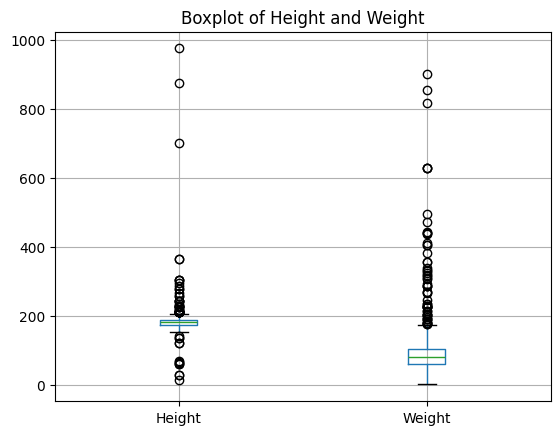

In [25]:
import matplotlib.pyplot as plt

df[["Height", "Weight"]].boxplot()
plt.title("Boxplot of Height and Weight")
plt.show()

Identify feature types

In [26]:
# Add these preprocessing steps:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical vs numerical columns
numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns
boolean_cols = X.select_dtypes(include=['bool']).columns

## Feature Types and Preprocessing

The dataset contains three main types of variables:

- Numerical variables, such as Height and Weight
- Categorical variables, such as Race, Publisher, and Alignment
- Boolean variables representing superhero powers, such as Flight, Magic, and Teleportation

Different preprocessing methods were applied depending on the variable type.

- Numerical variables were imputed using the median value and normalized using StandardScaler. The median was selected because the dataset contains several extreme values.

- Categorical variables were imputed using the most frequent category and transformed using OneHotEncoder.

- Boolean variables were passed through without scaling because they already represent binary information (True/False).

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# pipelines for different feature types
num_pipeline = Pipeline([
    ("imputer_median", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
#too much outlier for Height and Weight so i choose to use median to replace NaN
cat_pipeline = Pipeline([
    ("imputer_mode", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# column transformer
transformer = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols),
    ("bool", "passthrough", boolean_cols)
])

transformer.fit(X_train, y_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer_median',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Height', 'Weight'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer_mode',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Eye color', 'Ra...
                                ('bool', 'passthrough',
                                 Index(['Agility', 'Accelerated Healing', 'Lantern Power Ring',
       'Dimensional Awareness', 'Cold Resistance', 'Durability', 'Stealth',
       'Energy Absorption', 'Flight', 'Danger Sense',
       ...
       'Web Creation', 'Reality Warping', 'Odin Force', 'Symbiote Costume',
       'Speed Force', 'Phoenix Force', 'Molecular Dissipation',
       'Vision - Cryo', 'Omnipresent', 'Omniscient'],
      dtype='object', length=167))])

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

pipe_Logistic_Regression = Pipeline([
    ("preprocess", transformer),
    ('model_lr', LogisticRegression(random_state=42))
])

pipe_Logistic_Regression.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer_median',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Height', 'Weight'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer_mode',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=F...
                                                  Index(['Agility', 'Accelerated Healing', 'Lantern Power Ring',
       'Dimensional Awareness', 'Cold Resistance', 'Durability', 'Stealth',
       'Energy Absorption', 'Flight', 'Danger Sense',
       ...
       'Web Creation', 'Reality Warping', 'Odin Force', 'Symbiote Costume',
       'Speed Force', 'Phoenix Force', 'Molecular Dissipation',
       'Vision - Cryo', 'Omnipresent', 'Omniscient'],
      dtype='object', length=167))])),
                ('model_lr', LogisticRegression(random_state=42))])

The confusion matrix shows that the model predicts male characters more accurately than female characters. Many female characters were misclassified as male, suggesting that the dataset is imbalanced toward male characters.

              precision    recall  f1-score   support

      Female       0.68      0.37      0.48        41
        Male       0.76      0.92      0.83        88

    accuracy                           0.74       129
   macro avg       0.72      0.64      0.65       129
weighted avg       0.73      0.74      0.72       129



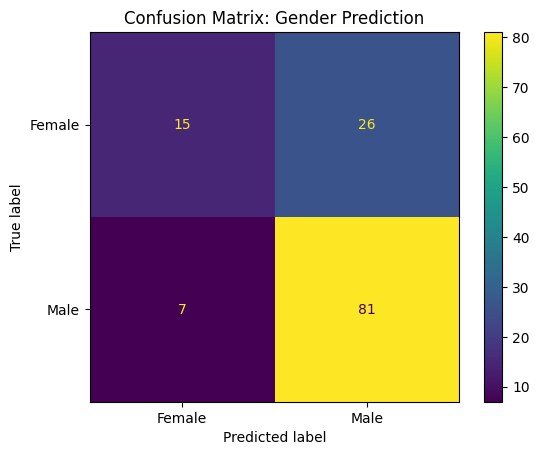

In [29]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# prediction
y_pred_Logistic_Regression = pipe_Logistic_Regression.predict(X_test)

# evaluation report
print(classification_report(y_test, y_pred_Logistic_Regression))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_Logistic_Regression)

plt.title("Confusion Matrix: Gender Prediction")
plt.show()

The classification report shows that the Random Forest model achieved an overall accuracy of about 81%. The model performed very well in predicting male characters, with a recall of 0.98 and an f1-score of 0.88. In contrast, the recall for female characters was only 0.46, meaning that many female characters were incorrectly classified. This indicates that the model is more effective at identifying male characters, likely because the dataset contains a larger number of male samples.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

pipe_random_forest = Pipeline([
    ("preprocess", transformer),
    ('model_lr', RandomForestClassifier(random_state=42))
])

pipe_random_forest.fit(X_train, y_train)

# Evaluate
y_pred_rf = pipe_random_forest.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.813953488372093
              precision    recall  f1-score   support

      Female       0.90      0.46      0.61        41
        Male       0.80      0.98      0.88        88

    accuracy                           0.81       129
   macro avg       0.85      0.72      0.75       129
weighted avg       0.83      0.81      0.79       129



The bar chart shows that the model predicted significantly more male characters than female characters. This suggests that the model is biased toward predicting the male class, likely because the dataset contains a much larger number of male samples than female samples.

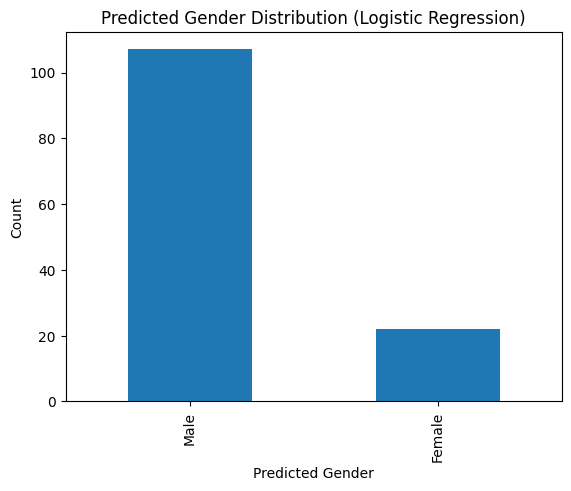

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert y_pred_Logistic_Regression to a pandas Series to use value_counts()
pd.Series(y_pred_Logistic_Regression).value_counts().plot(kind='bar')
plt.title('Predicted Gender Distribution (Logistic Regression)')
plt.xlabel('Predicted Gender')
plt.ylabel('Count')
plt.show()

## Interpreting Logistic Regression Coefficients

To understand which variables are most influential in the Logistic Regression model, we can examine the coefficients assigned to each feature. The absolute magnitude of a coefficient indicates the strength of the relationship, while the sign (positive or negative) indicates the direction.

First, we need to get the feature names after all preprocessing steps (imputation, scaling, one-hot encoding) applied by the `ColumnTransformer`.

In [32]:
import numpy as np

# Get feature names after ColumnTransformer preprocessing
# For numerical features, `get_feature_names_out()` will give scaled names
num_feature_names = transformer.named_transformers_['num'].get_feature_names_out(numerical_cols)

# For categorical features, `get_feature_names_out()` will give one-hot encoded names
cat_feature_names = transformer.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# For boolean features (passthrough), their names remain unchanged
bool_feature_names = boolean_cols.tolist()

# Combine all feature names
all_feature_names = np.concatenate([num_feature_names, cat_feature_names, bool_feature_names])

print(f"Total features after preprocessing: {len(all_feature_names)}")
# print(all_feature_names[:10]) # Print first 10 for inspection

Total features after preprocessing: 287


Now, let's extract the coefficients from the `LogisticRegression` model within the pipeline and pair them with their respective feature names. We'll then sort them by their absolute value to highlight the most impactful features.

In [33]:
import pandas as pd

# Get the Logistic Regression model from the pipeline
logistic_model = pipe_Logistic_Regression.named_steps['model_lr']

# Get the coefficients. For binary classification, coef_ will have shape (1, n_features)
coefficients = logistic_model.coef_[0]

# Create a DataFrame to display feature names and their coefficients
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value to see the most important features
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 20 most influential features in Logistic Regression:")
display(feature_importance_df.head(20))

Top 20 most influential features in Logistic Regression:


,Feature,Coefficient,Abs_Coefficient
86,Hair color_No Hair,1.827941,1.827941
88,Hair color_Red,-1.216969,1.216969
160,Energy Beams,1.199153,1.199153
9,Eye color_green,-1.059403,1.059403
29,Race_Asgardian,-1.057716,1.057716
211,Gliding,0.978347,0.978347
225,Time Travel,0.977454,0.977454
193,Photographic Reflexes,-0.952657,0.952657
217,Light Control,-0.885919,0.885919
242,Telepathy Resistance,-0.879092,0.879092


/tmp/ipykernel_421/2723030703.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_20_features, palette=colors)


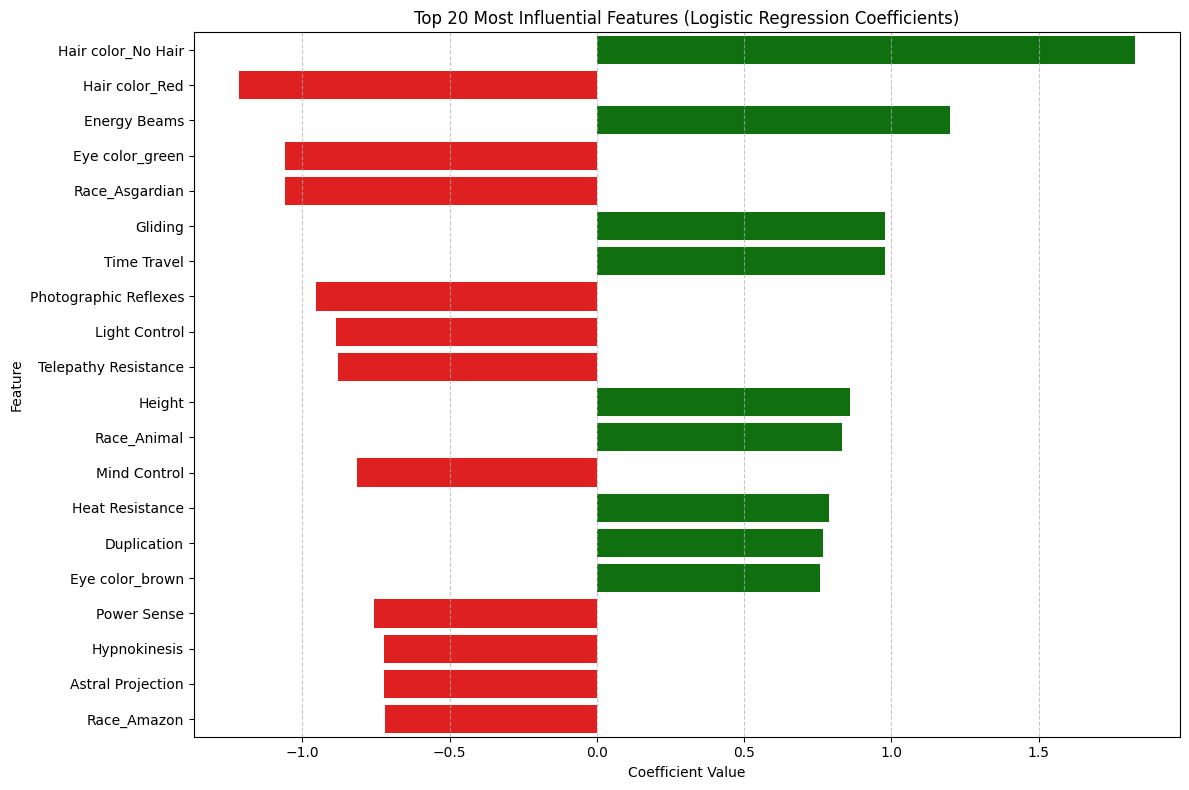

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 20 most influential features
top_20_features = feature_importance_df.head(20)

# Create a color map for positive and negative coefficients
colors = ['red' if c < 0 else 'green' for c in top_20_features['Coefficient']]

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_20_features, palette=colors)
plt.title('Top 20 Most Influential Features (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

From the table above, we can identify the most useful variables based on the magnitude of their 'Abs_Coefficient'. A positive coefficient suggests that an increase in that feature's value (or its presence for one-hot encoded categorical/boolean features) makes the model more likely to predict the class corresponding to the positive label (e.g., 'Male' if 'Male' is encoded as 1). Conversely, a negative coefficient suggests a tendency towards the negative label (e.g., 'Female').

For example:
*   Features with high positive coefficients heavily contribute to predicting 'Male'.
*   Features with high negative coefficients heavily contribute to predicting 'Female'.

This analysis helps to understand the drivers behind the model's predictions for superhero gender.

In [35]:
import numpy as np

# Get the classes from the fitted model
classes = logistic_model.classes_

print(f"Model Classes: {classes}")
print(f"Class 0 (Negative): {classes[0]}")
print(f"Class 1 (Positive): {classes[1]}")

# Explain interpretation based on the actual classes found
if classes[1] == 'Male':
    print("\nInterpretation: 'Male' is the positive class (1). Positive coefficients increase the likelihood of being Male.")
else:
    print("\nInterpretation: 'Female' is the positive class (1). Positive coefficients increase the likelihood of being Female.")

Model Classes: ['Female' 'Male']
Class 0 (Negative): Female
Class 1 (Positive): Male

Interpretation: 'Male' is the positive class (1). Positive coefficients increase the likelihood of being Male.


### RandomForest Feature Importance Analysis

Unlike Logistic Regression, which uses coefficients to show direction and magnitude, Random Forest provides an 'Importance' score based on how much each feature contributes to the model's ability to split the data effectively.

Top 20 Features in Random Forest:


,Feature,Importance
1,Weight,0.171369
0,Height,0.104356
9,Eye color_green,0.019830
88,Hair color_Red,0.019656
76,Hair color_Blond,0.015199
118,Alignment_bad,0.014948
86,Hair color_No Hair,0.013704
107,Publisher_Marvel Comics,0.013250
7,Eye color_brown,0.012899
136,Intelligence,0.012882


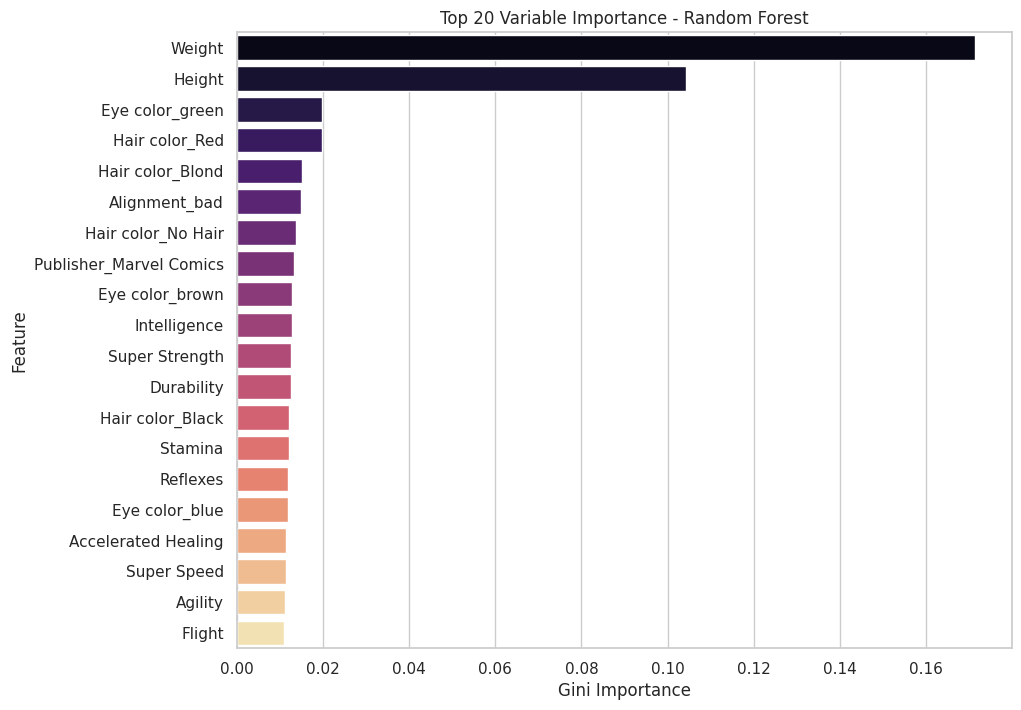

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the model from the pipeline (using the correct step name 'model_lr')
rf_model = pipe_random_forest.named_steps['model_lr']

# 2. Get the importance scores
importances = rf_model.feature_importances_

# 3. Create a DataFrame for visualization using 'all_feature_names' created earlier
rf_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Display the top 20
print("Top 20 Features in Random Forest:")
display(rf_importance_df.head(20))

# 5. Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(20), hue='Feature', palette='magma', legend=False)
plt.title('Top 20 Variable Importance - Random Forest')
plt.xlabel('Gini Importance')
plt.show()

The bar plot above visually represents the most important features as determined by the RandomForestClassifier. Features with longer bars (higher importance scores) contribute more significantly to the model's predictions. Unlike Logistic Regression coefficients which indicate direction (positive/negative), feature importances in RandomForest are always positive and only indicate the magnitude of influence.

### Comparison of Feature Importance：Logistic Regression vs. Random Forest

The figures below compare the absolute coefficients from Logistic Regression with the feature importances from Random Forest

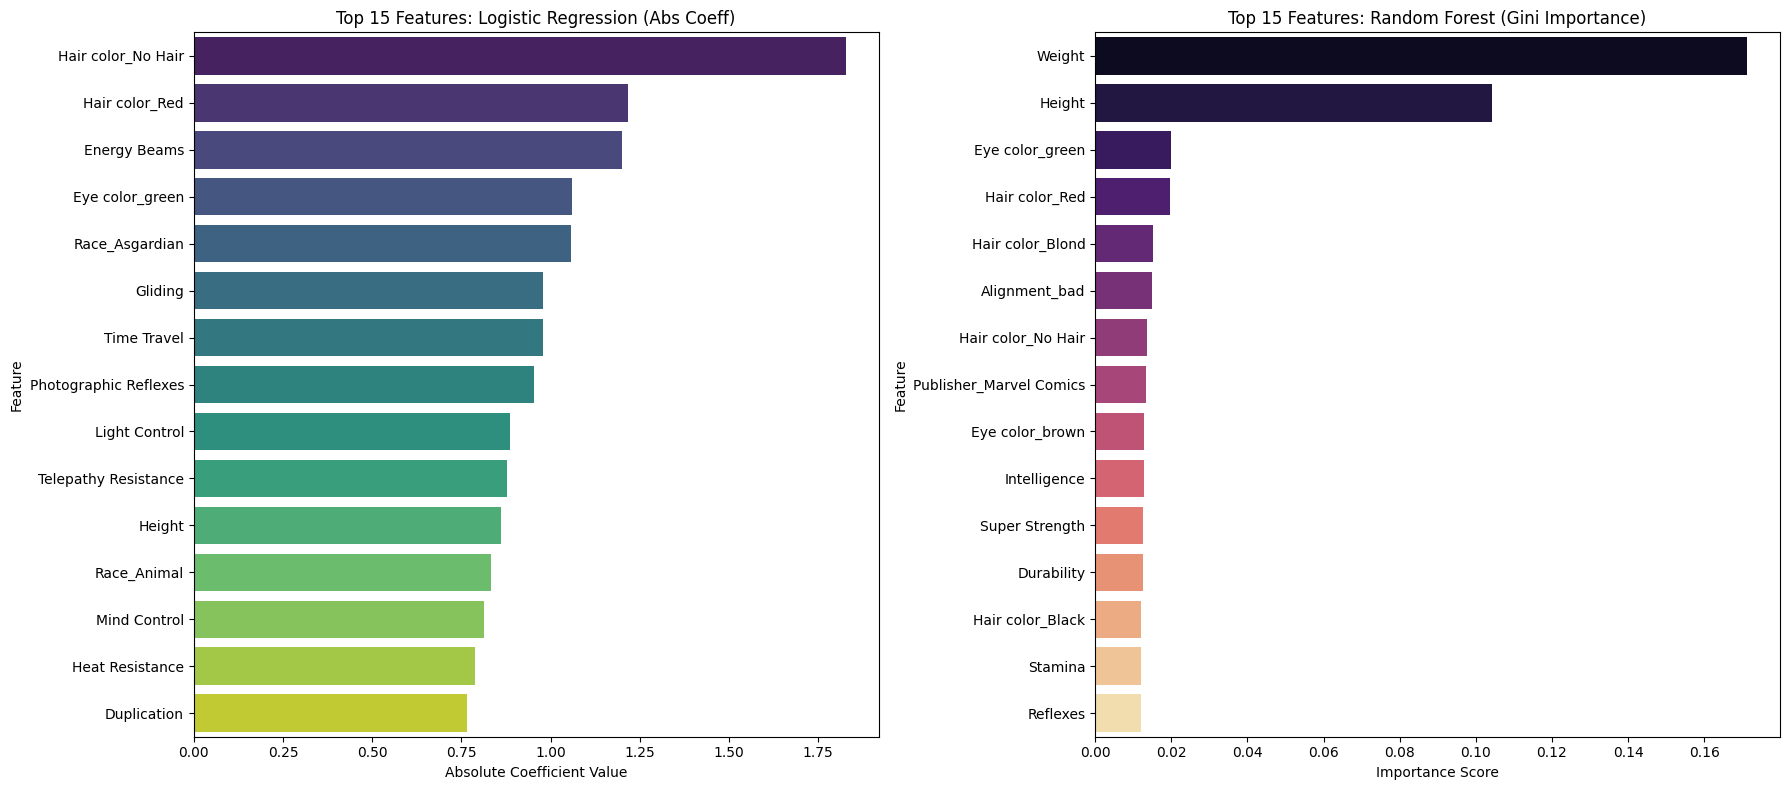

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for comparison
# We use Absolute Coefficients for Logistic Regression to compare 'strength' with RF Importance
lr_top = feature_importance_df.sort_values('Abs_Coefficient', ascending=False).head(15)
rf_top = rf_importance_df.sort_values('Importance', ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot Logistic Regression (Absolute Strength)
# Fixed: Added hue='Feature' and legend=False to resolve FutureWarning
sns.barplot(x='Abs_Coefficient', y='Feature', data=lr_top, ax=ax1, hue='Feature', palette='viridis', legend=False)
ax1.set_title('Top 15 Features: Logistic Regression (Abs Coeff)')
ax1.set_xlabel('Absolute Coefficient Value')

# Plot Random Forest Importance
# Fixed: Added hue='Feature' and legend=False to resolve FutureWarning
sns.barplot(x='Importance', y='Feature', data=rf_top, ax=ax2, hue='Feature', palette='magma', legend=False)
ax2.set_title('Top 15 Features: Random Forest (Gini Importance)')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Key Findings and Insights from Model Analysis

Through an in-depth analysis of both Logistic Regression and Random Forest models, we obtained several key insights regarding superhero gender prediction:

### 1. Model Performance Comparison
- Random Forest ( around 81% accuracy) outperformed Logistic Regression (around 74% accuracy), suggesting the presence of complex non-linear relationships between features and gender.
- Both models predicted male characters more accurately due to class imbalance in the dataset.

### 2. Key Feature Insights (Feature Importance)
- Weight and Height were the most influential features in Random Forest.
- No Hair showed a strong positive association with male predictions showed a strong positive association with male predictions in Logistic Regression.

### 3. Differences in Model Interpretability
- Logistic Regression explains prediction direction through positive and negative coefficients.
- Random Forest highlights feature importance but does not directly indicate prediction direction.

### 4. Practical Insights
Some feature–gender relationships may reflect common stereotypes in comic character design, such as stronger male characters or red-haired female characters. These findings reveal not only statistical patterns but also trends in popular culture

### Distribution Analysis of Key Features and Gender

To better understand the model's decision-making process, we visualized the distributions of the most important numerical features (e.g., height and weight) and categorical features (e.g., no hair and red hair)

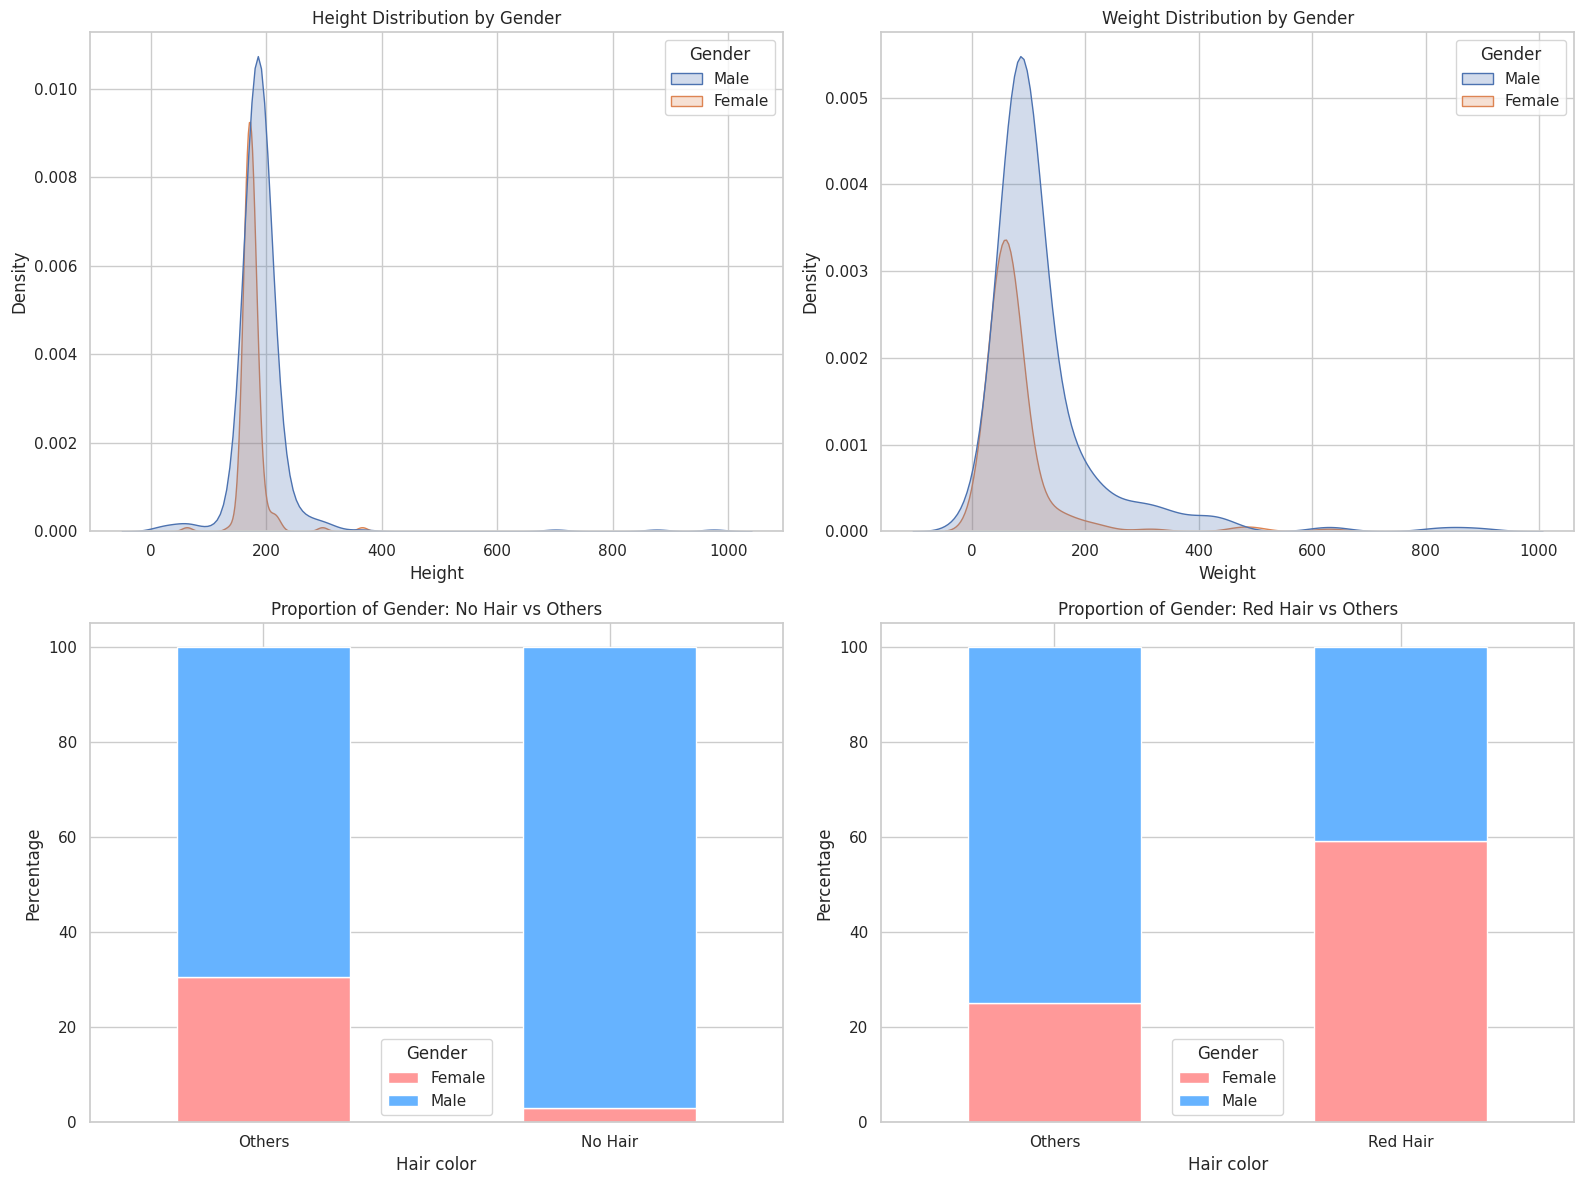

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configure the illustration style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Height (Numerical Feature)
sns.kdeplot(data=df, x="Height", hue="Gender", fill=True, ax=axes[0, 0])
axes[0, 0].set_title("Height Distribution by Gender")

# 2. Weight Distribution - Numerical Feature
sns.kdeplot(data=df, x="Weight", hue="Gender", fill=True, ax=axes[0, 1])
axes[0, 1].set_title("Weight Distribution by Gender")

# 3. No Hair vs. Gender – Most Important Logistic Regression Feature
# Create a contingency table and draw a normalized stacked bar chart
hair_gender = pd.crosstab(df['Hair color'] == 'No Hair', df['Gender'], normalize='index') * 100
hair_gender.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#ff9999','#66b3ff'])
axes[1, 0].set_title("Proportion of Gender: No Hair vs Others")
axes[1, 0].set_xticklabels(['Others', 'No Hair'], rotation=0)
axes[1, 0].set_ylabel("Percentage")

# 4. Red Hair and Gender Relationship
red_hair_gender = pd.crosstab(df['Hair color'] == 'Red', df['Gender'], normalize='index') * 100
red_hair_gender.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#ff9999','#66b3ff'])
axes[1, 1].set_title("Proportion of Gender: Red Hair vs Others")
axes[1, 1].set_xticklabels(['Others', 'Red Hair'], rotation=0)
axes[1, 1].set_ylabel("Percentage")

plt.tight_layout()
plt.show()